In [25]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
from torchvision import models
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [26]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


# preprocessing

In [ ]:
# Minority class (label = 1)
minority_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),  
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Majority class (label = 0)
majority_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [28]:
class ImbalancedDataset:
    def __init__(self, root):
        self.dataset = ImageFolder(root=root)
        self.classes = self.dataset.classes

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        img, label = self.dataset[idx]

        if label == 1:
            img = minority_transform(img)
        else:
            img = majority_transform(img)

        return img, label

In [29]:
train_dataset = ImbalancedDataset('archive/train')

base_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_dataset = ImageFolder('archive/valid', transform=base_transform)
test_dataset = ImageFolder('archive/test', transform=base_transform)

print("Classes:", train_dataset.classes)

Classes: ['0', '1']


# weighted sampling (oversample minority class when training)

In [30]:
from torch.utils.data import WeightedRandomSampler
labels = [label for _, label in train_dataset.dataset.samples]

class_counts = np.bincount(labels)
weights = 1. / class_counts
sample_weights = [weights[label] for label in labels]

sampler = WeightedRandomSampler(sample_weights, len(sample_weights), replacement=True)

In [31]:
train_loader = DataLoader(train_dataset, batch_size=32, sampler=sampler, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

# resnet

In [32]:
def build_resnet(num_classes):
    model = models.resnet18(weights="IMAGENET1K_V1")

    #freeze backbone
    for param in model.parameters():
        param.requires_grad = False

    #replace classifier
    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features, num_classes)

    #unfreeze last block
    for param in model.layer4.parameters():
        param.requires_grad = True

    return model

# train func

In [33]:
def train_model(model, train_loader, val_loader, epochs, lr):

    model = model.to(device)
    class_weights = torch.tensor([1/1569, 1/803]).to(device)
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=lr)

    for epoch in range(epochs):
        model.train()
        total_loss = 0

        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        avg_loss = total_loss / len(train_loader)
        print(f"Epoch {epoch+1}/{epochs} - Loss: {avg_loss:.4f}")

        validate(model, val_loader)

# validate n eval

In [34]:
def validate(model, val_loader):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    acc = correct / total
    print("Validation Accuracy:", acc)

In [35]:
def test_model(model, test_loader):

    model.eval()

    y_true = []
    y_pred = []
    y_prob = []

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)

            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)
            _, predicted = torch.max(outputs, 1)

            y_true.extend(labels.numpy())
            y_pred.extend(predicted.cpu().numpy())
            y_prob.extend(probs[:,1].cpu().numpy())

    print("\nClassification Report")
    print(classification_report(y_true, y_pred))
    cm = confusion_matrix(y_true, y_pred)

    plt.figure()
    sns.heatmap(cm, annot=True, fmt="d")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix")
    plt.show()

    try:
        auc = roc_auc_score(y_true, y_prob)
        print("ROC AUC:", auc)
    except:
        pass

# run resnet

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /home/tiffie/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100.0%


Epoch 1/10 - Loss: 0.5911
Validation Accuracy: 0.5866666666666667
Epoch 2/10 - Loss: 0.4193
Validation Accuracy: 0.5911111111111111
Epoch 3/10 - Loss: 0.3193
Validation Accuracy: 0.5288888888888889
Epoch 4/10 - Loss: 0.2341
Validation Accuracy: 0.6325925925925926
Epoch 5/10 - Loss: 0.1881
Validation Accuracy: 0.6074074074074074
Epoch 6/10 - Loss: 0.1820
Validation Accuracy: 0.5748148148148148
Epoch 7/10 - Loss: 0.1169
Validation Accuracy: 0.6325925925925926
Epoch 8/10 - Loss: 0.0699
Validation Accuracy: 0.6281481481481481
Epoch 9/10 - Loss: 0.0823
Validation Accuracy: 0.6414814814814814
Epoch 10/10 - Loss: 0.0514
Validation Accuracy: 0.6385185185185185

Classification Report
              precision    recall  f1-score   support

           0       0.75      0.61      0.67       208
           1       0.51      0.68      0.59       128

    accuracy                           0.63       336
   macro avg       0.63      0.64      0.63       336
weighted avg       0.66      0.63      0.64 

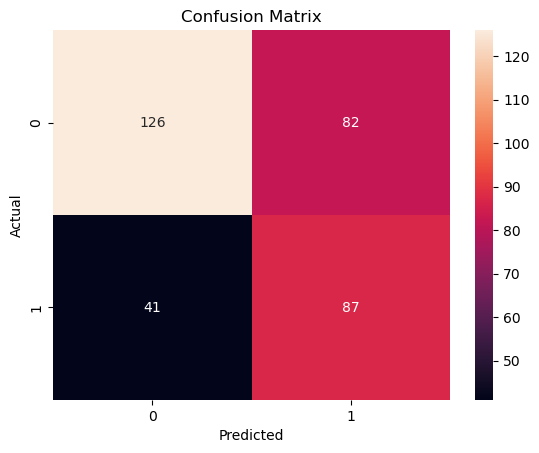

ROC AUC: 0.6943734975961539


In [36]:
num_classes =  len(train_dataset.classes)
model_resnet = build_resnet(num_classes)

train_model(
    model=model_resnet,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=10,
    lr=1e-4
)

test_model(model_resnet, test_loader)

In [ ]:
torch.save(
    model_resnet.state_dict(),
    "breastcancer_resnet18.pth"
)

print("savedeuh")